# NPK, Temperature and Humidity prediction

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from xgboost import XGBRegressor
import joblib
import matplotlib.pyplot as plt

In [2]:
crop_data = pd.read_csv('data/crop_data.csv')

In [3]:
crop_data.columns

Index(['STATE', 'SOIL_TYPE', 'N_SOIL', 'P_SOIL', 'K_SOIL', 'TEMPERATURE',
       'HUMIDITY', 'ph', 'RAINFALL', 'CROP_PRICE', 'CROP'],
      dtype='object')

In [4]:
crop_data['STATE'].unique(),crop_data['SOIL_TYPE'].unique(),crop_data['CROP'].unique(),

(array(['Andaman and Nicobar', 'Andhra Pradesh', 'Assam', 'Chattisgarh',
        'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh',
        'Jammu and Kashmir', 'Karnataka', 'Kerala', 'Madhya Pradesh',
        'Maharashtra', 'Manipur', 'Meghalaya', 'Nagaland', 'Odisha',
        'Pondicherry', 'Punjab', 'Rajasthan', 'Tamil Nadu', 'Telangana',
        'Tripura', 'Uttar Pradesh', 'Uttrakhand', 'West Bengal'],
       dtype=object),
 array(['Sandy soil', 'Red soil', 'Laterite soil', 'Clayey soils',
        'Desert soils', 'Desert soil', 'Sandy loam', 'Alluvial soil',
        'Sandy Clay loam', 'Black soil', 'Regur soil', 'Inceptisols',
        'Loamy soil', 'Delta alluvium', 'Mountain soil.'], dtype=object),
 array(['Amaranthus', 'Green Banana', 'Ladies Finger', 'Bitter Gourd',
        'Black pepper', 'Bottle Gourd', 'Brinjal', 'Cabbage', 'Carrot',
        'Cauliflower', 'Cluster beans', 'Coconut', 'Colacasia', 'Onion',
        'Potato', 'Tomato', 'Bengal Gram', 'Jowar', 'Paddy', 'Lentil',
  

In [5]:
# --- 1. Rename crops ---
crop_rename_map = {
    'Green Banana': 'Banana',
    'Raddish': 'Radish',
    'Paddy': 'Rice'
}
crop_data['CROP'] = crop_data['CROP'].replace(crop_rename_map)

# --- 2. Rename states ---
state_rename_map = {
    'Uttrakhand': 'Uttarakhand'
}
crop_data['STATE'] = crop_data['STATE'].replace(state_rename_map)

# --- 3. Rename soil types ---
soil_rename_map = {
    'Desert soils': 'Desert soil',
    'Clayey soils': 'Clayey soil',
    'Mountain soil.': 'Mountain soil',
    'Regur soil':'Black soil'
}
crop_data['SOIL_TYPE'] = crop_data['SOIL_TYPE'].replace(soil_rename_map)

def clean_soil_name(soil):
    soil = soil.strip().replace('.', '')  # remove trailing dot if any
    if not soil.lower().endswith('soil'):
        soil += ' soil'
    return soil

crop_data['SOIL_TYPE'] = crop_data['SOIL_TYPE'].apply(clean_soil_name)


In [6]:
# Print final unique values for verification
print("✅ Unique Soil Types:", crop_data['SOIL_TYPE'].nunique())
print("✅ Unique States:", crop_data['STATE'].nunique())
print("✅ Unique Crops:", crop_data['CROP'].nunique())

✅ Unique Soil Types: 13
✅ Unique States: 26
✅ Unique Crops: 147


In [7]:
print("Dataset shape:", crop_data.shape)

Dataset shape: (2200, 11)


### Feature Encoding 

In [8]:
# Encode categorical columns
le_state = LabelEncoder()
le_soil = LabelEncoder()
le_crop = LabelEncoder()

crop_data['STATE_ENC'] = le_state.fit_transform(crop_data['STATE'])
crop_data['SOIL_ENC'] = le_soil.fit_transform(crop_data['SOIL_TYPE'])
crop_data['CROP_ENC'] = le_crop.fit_transform(crop_data['CROP'])


In [9]:
print(le_state.classes_)
print(le_crop.classes_)
print(le_soil.classes_)

['Andaman and Nicobar' 'Andhra Pradesh' 'Assam' 'Chattisgarh' 'Goa'
 'Gujarat' 'Haryana' 'Himachal Pradesh' 'Jammu and Kashmir' 'Karnataka'
 'Kerala' 'Madhya Pradesh' 'Maharashtra' 'Manipur' 'Meghalaya' 'Nagaland'
 'Odisha' 'Pondicherry' 'Punjab' 'Rajasthan' 'Tamil Nadu' 'Telangana'
 'Tripura' 'Uttar Pradesh' 'Uttarakhand' 'West Bengal']
['Amaranthus' 'Amla' 'Amphophalus' 'Apple' 'Arecanut' 'Ash Gourd' 'Bajra'
 'Banana' 'Barley' 'Beans' 'Beetroot' 'Bengal Gram' 'Betal Leaves'
 'Bitter Gourd' 'Black Gram' 'Black pepper' 'Bottle Gourd' 'Brinjal'
 'Broken Rice' 'Cabbage' 'Capsicum' 'Carrot' 'Cashewnuts' 'Castor Seed'
 'Cauliflower' 'Chana Dal' 'Chholia' 'Chilly Capsicum' 'Cluster Beans'
 'Cluster beans' 'Coconut' 'Coconut Oil' 'Coconut Seed' 'Colacasia'
 'Copra' 'Coriander' 'Corriander seed' 'Cotton' 'Cowpea' 'Cucumber'
 'Cumbu' 'Drumstick' 'Dry Chillies' 'Duster Beans' 'Elephat Yam'
 'Field Pea' 'Fish' 'French Beans' 'Garlic' 'Ghee' 'Gingelly Oil' 'Ginger'
 'Grapes' 'Green Avare' 'Green 

In [10]:
# ✅ NPK Prediction Model
X_npk = crop_data[['STATE_ENC', 'SOIL_ENC', 'CROP_ENC', 'TEMPERATURE', 'HUMIDITY', 'RAINFALL', 'ph']]
y_npk = crop_data[['N_SOIL', 'P_SOIL', 'K_SOIL']]

X_train, X_test, y_train, y_test = train_test_split(X_npk, y_npk, test_size=0.2, random_state=42)


In [11]:
# Train Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

# (Optional) Check R2 Score
print("Random Forest R2 Score:", rf_model.score(X_test, y_test))


Random Forest R2 Score: 0.8652625298443728


In [12]:
# OPTIONAL: XGBoost Model
xgb_model = XGBRegressor(objective='reg:squarederror', n_estimators=200, random_state=42)
xgb_model.fit(X_train, y_train)
print("XGBoost R2 Score:", xgb_model.score(X_test, y_test))

XGBoost R2 Score: 0.8685778820607654


In [13]:
rf_model = RandomForestRegressor(
    max_depth=10,
    min_samples_split=2,
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)
print("Tuned Random Forest R2 Score:", rf_model.score(X_test, y_test))


Tuned Random Forest R2 Score: 0.8661784239956957


In [14]:
# XGBoost Regressor (Tuned)
xgb_npk_model = XGBRegressor(
    max_depth=10,
    n_estimators=200,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42
)
xgb_npk_model.fit(X_train, y_train)

# Evaluate NPK Model
xgb_npk_pred = xgb_npk_model.predict(X_test)
npk_r2 = r2_score(y_test, xgb_npk_pred)
print("✅ Tuned XGBoost NPK Model R2 Score:", npk_r2)


✅ Tuned XGBoost NPK Model R2 Score: 0.8823256470043965


In [15]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

# Select only encoded and numeric features
X = crop_data[['STATE_ENC', 'SOIL_ENC', 'CROP_ENC', 'RAINFALL']]
y = crop_data[['TEMPERATURE', 'HUMIDITY']]  

X_th_train, X_th_test, y_th_train, y_th_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define parameter grid for tuning
param_dist = {
    'n_estimators': [600, 800, 1000, 1200, 1500, 1600],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}


# Run Randomized Search only on one target column (e.g., Temperature) for speed
rf = RandomForestRegressor(random_state=42)
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,                # number of parameter combinations to try
    cv=3,
    scoring='r2',
    n_jobs=1,
    verbose=1,
    random_state=42
)
random_search.fit(X_th_train, y_th_train.iloc[:, 0])  # Tune only for Temperature

# Show best parameters
print("✅ Best Parameters from RandomizedSearchCV:", random_search.best_params_)

# Train final model using best parameters on both Temperature & Humidity
best_rf = RandomForestRegressor(**random_search.best_params_, random_state=42)
temp_hum_model = MultiOutputRegressor(best_rf)
temp_hum_model.fit(X_th_train, y_th_train)

# Predict and evaluate
y_th_pred = temp_hum_model.predict(X_th_test)
th_r2 = r2_score(y_th_test, y_th_pred)

print("✅ Tuned Temperature & Humidity Model R2 Score:", th_r2)


Fitting 3 folds for each of 20 candidates, totalling 60 fits
✅ Best Parameters from RandomizedSearchCV: {'n_estimators': 600, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 10}
✅ Tuned Temperature & Humidity Model R2 Score: 0.6201691063356923


<Figure size 1000x600 with 0 Axes>

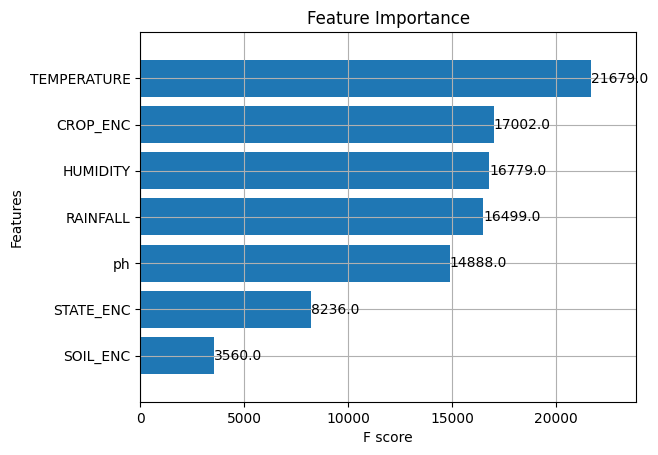

In [16]:
from xgboost import plot_importance
# Plot feature importance
plt.figure(figsize=(10, 6))
plot_importance(xgb_npk_model, importance_type='weight', max_num_features=10, height=0.8)
plt.title('Feature Importance')
plt.show()



### Save Model

In [17]:
# ✅ Save Models and Encoders for Flask or Future Use
joblib.dump(xgb_npk_model, 'models/predict_npk_xgb_model.pkl')
joblib.dump(temp_hum_model, 'models/predict_temp_hum_model.pkl')
joblib.dump(le_state, 'models/predict_state_encoder.pkl')
joblib.dump(le_soil, 'models/predict_soil_encoder.pkl')
joblib.dump(le_crop, 'models/predict_crop_encoder.pkl')

print("🎯 All Models and Encoders Saved Successfully!")

🎯 All Models and Encoders Saved Successfully!


### Testing

In [18]:
# ✅ Load Models and Encoders
npk_model = joblib.load('models/predict_npk_xgb_model.pkl')
temp_hum_model = joblib.load('models/predict_temp_hum_model.pkl')
le_state = joblib.load('models/predict_state_encoder.pkl')
le_soil = joblib.load('models/predict_soil_encoder.pkl')
le_crop = joblib.load('models/predict_crop_encoder.pkl')

print("✅ Models and Encoders Loaded Successfully!")

✅ Models and Encoders Loaded Successfully!


In [19]:
# ✅ Example User Input
user_state = 'Maharashtra'
user_soil = 'Black soil'
user_crop = 'Soyabean'
user_rainfall = 850   
ph_value = 6.5        

In [20]:
# ✅ Encode the user input
state_enc = le_state.transform([user_state])[0]
soil_enc = le_soil.transform([user_soil])[0]
crop_enc = le_crop.transform([user_crop])[0]

# Predict Temperature & Humidity
temp_hum_input_df = pd.DataFrame([[state_enc, soil_enc, crop_enc, user_rainfall]],
                                 columns=['STATE_ENC', 'SOIL_ENC', 'CROP_ENC', 'RAINFALL'])
pred_temp_hum = temp_hum_model.predict(temp_hum_input_df)[0]

# ✅ Unpack the predictions
pred_temp, pred_hum = pred_temp_hum
print(f"🌡️ Predicted Temperature: {pred_temp:.2f} °C")
print(f"💧 Predicted Humidity: {pred_hum:.2f} %")

# Predict NPK values
npk_input_df = pd.DataFrame([[state_enc, soil_enc, crop_enc, pred_temp_hum[0], pred_temp_hum[1], user_rainfall, ph_value]],
                            columns=['STATE_ENC', 'SOIL_ENC', 'CROP_ENC', 'TEMPERATURE', 'HUMIDITY', 'RAINFALL', 'ph'])
pred_npk = npk_model.predict(npk_input_df)[0]

print("\n✅ Predicted NPK Values:")
print(f"🟢 Nitrogen (N): {pred_npk[0]:.2f}")
print(f"🟠 Phosphorous (P): {pred_npk[1]:.2f}")
print(f"🔵 Potassium (K): {pred_npk[2]:.2f}")

# ✅ Optional - Output as DataFrame
result_df = pd.DataFrame({
    'State': [user_state],
    'Soil Type': [user_soil],
    'Crop': [user_crop],
    'Rainfall (mm)': [user_rainfall],
    'Predicted Temperature (°C)': [pred_temp],
    'Predicted Humidity (%)': [pred_hum],
    'Nitrogen (N)': [pred_npk[0]],
    'Phosphorous (P)': [pred_npk[1]],
    'Potassium (K)': [pred_npk[2]]
})

result_df


🌡️ Predicted Temperature: 31.28 °C
💧 Predicted Humidity: 70.00 %

✅ Predicted NPK Values:
🟢 Nitrogen (N): 36.32
🟠 Phosphorous (P): 68.39
🔵 Potassium (K): 21.82


,State,Soil Type,Crop,Rainfall (mm),Predicted Temperature (°C),Predicted Humidity (%),Nitrogen (N),Phosphorous (P),Potassium (K)
0,Maharashtra,Black soil,Soyabean,850,31.284538,70.00242,36.32143,68.393959,21.815159


# Yeild Prediction

In [21]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.preprocessing import LabelEncoder
import joblib
import os

In [22]:
crop_yield = pd.read_csv('data/Crop_Yield.csv')
crop_yield.columns

Index(['crop', 'year', 'season', 'state', 'area', 'production',
       'annual rainfall', 'yield'],
      dtype='object')

In [23]:
# ✅ Check required columns
required_columns = ['crop', 'year', 'season', 'state', 'area', 'production', 'annual rainfall', 'yield']
if not all(col in crop_yield.columns for col in required_columns):
    raise ValueError("❌ Missing required columns in crop_yield!")

print("✅ All required columns are present!")

✅ All required columns are present!


In [24]:
# ✅ Encode categorical columns
le_crop = LabelEncoder()
le_season = LabelEncoder()
le_state = LabelEncoder()

crop_yield['crop_enc'] = le_crop.fit_transform(crop_yield['crop'])
crop_yield['season_enc'] = le_season.fit_transform(crop_yield['season'])
crop_yield['state_enc'] = le_state.fit_transform(crop_yield['state'])

In [25]:
# ✅ Define features and target
features = ['crop_enc', 'year', 'season_enc', 'state_enc', 'area', 'annual rainfall']
target = 'yield'

X = crop_yield[features]
y = crop_yield[target]

In [26]:
# ✅ Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [27]:
# ✅ Train RandomForest Regressor
rf_yield = RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42)
rf_yield.fit(X_train, y_train)
rf_pred = rf_yield.predict(X_test)
rf_r2 = r2_score(y_test, rf_pred)
print(f"✅ RandomForest Yield R2 Score: {rf_r2:.4f}")

✅ RandomForest Yield R2 Score: 0.8840


In [28]:
# ✅ Train XGBoost Regressor
xgb_yield = XGBRegressor(n_estimators=300, max_depth=12, learning_rate=0.1,
                         subsample=0.8, colsample_bytree=0.8, random_state=42)
xgb_yield.fit(X_train, y_train)
xgb_pred = xgb_yield.predict(X_test)
xgb_r2 = r2_score(y_test, xgb_pred)
print(f"✅ XGBoost Yield R2 Score: {xgb_r2:.4f}")

✅ XGBoost Yield R2 Score: 0.8544


In [29]:
# 🔥 Create a models folder
os.makedirs('models', exist_ok=True)
joblib.dump(xgb_yield, 'models/predict_xgb_yield_model.pkl')
print("✅ XGBoost Yield Model saved successfully!")

✅ XGBoost Yield Model saved successfully!


### Testing

In [30]:

# ✅ Load the model
loaded_model = joblib.load('models/predict_xgb_yield_model.pkl')

# ✅ Create sample input with the correct feature names
sample = pd.DataFrame([{
    'crop_enc': 3,            # example encoded crop
    'year': 2025,
    'season_enc': 1,          # example encoded season
    'state_enc': 5,           # example encoded state
    'area': 4,             # in hectares
    'annual rainfall': 550    # in mm
}])

# ✅ Predict the yield
prediction = loaded_model.predict(sample)

print(f"✅ Predicted Yield: {prediction[0]:.2f} tons/hectare")


✅ Predicted Yield: 4.17 tons/hectare


In [31]:
import joblib
import numpy as np
import pandas as pd

# ✅ Load Models and Encoders
npk_model = joblib.load('models/predict_npk_xgb_model.pkl')
temp_hum_model = joblib.load('models/predict_temp_hum_model.pkl')
yield_model = joblib.load('models/predict_xgb_yield_model.pkl')
le_state = joblib.load('models/predict_state_encoder.pkl')
le_soil = joblib.load('models/predict_soil_encoder.pkl')
le_crop = joblib.load('models/predict_crop_encoder.pkl')

print("✅ Models and Encoders Loaded Successfully!")

# ✅ Unified User Inputs (Only 5 inputs)
user_state = 'Madhya Pradesh'
user_soil = 'Black soil'
user_crop = 'Soyabean'
user_area = 1500                 # in hectares

# ✅ Encode the categorical inputs
state_enc = le_state.transform([user_state])[0]
soil_enc = le_soil.transform([user_soil])[0]
crop_enc = le_crop.transform([user_crop])[0]

# ✅ Predict Temperature & Humidity
temp_hum_input = pd.DataFrame([[state_enc, soil_enc, crop_enc, user_rainfall]],
                              columns=['STATE_ENC', 'SOIL_ENC', 'CROP_ENC', 'RAINFALL'])
pred_temp, pred_hum = temp_hum_model.predict(temp_hum_input)[0]

print(f"🌡️ Predicted Temperature: {pred_temp:.2f} °C")
print(f"💧 Predicted Humidity: {pred_hum:.2f} %")

# ✅ Predict NPK values (Optional default pH value added)
ph_value = 6.5
npk_input = pd.DataFrame([[state_enc, soil_enc, crop_enc, pred_temp, pred_hum, user_rainfall, ph_value]],
                         columns=['STATE_ENC', 'SOIL_ENC', 'CROP_ENC', 'TEMPERATURE', 'HUMIDITY', 'RAINFALL', 'ph'])
pred_N, pred_P, pred_K = npk_model.predict(npk_input)[0]

print("\n✅ Predicted NPK Values:")
print(f"🟢 Nitrogen (N): {pred_N:.2f}")
print(f"🟠 Phosphorous (P): {pred_P:.2f}")
print(f"🔵 Potassium (K): {pred_K:.2f}")

# ✅ Predict Yield
yield_input = pd.DataFrame([{
    'crop_enc': crop_enc,
    'year': 2023,
    'season_enc': 1,  # Assume 'Kharif' encoded as 1
    'state_enc': state_enc,
    'area': user_area,
    'annual rainfall': user_rainfall
}])

predicted_yield = yield_model.predict(yield_input)[0]
print(f"\n🌾 Predicted Yield: {predicted_yield:.2f} tons/hectare")

# ✅ Final Result DataFrame (Optional)
result = pd.DataFrame({
    'State': [user_state],
    'Soil Type': [user_soil],
    'Crop': [user_crop],
    'Area (ha)': [user_area],
    'Rainfall (mm)': [user_rainfall],
    'Temperature (°C)': [pred_temp],
    'Humidity (%)': [pred_hum],
    'Nitrogen (N)': [pred_N],
    'Phosphorous (P)': [pred_P],
    'Potassium (K)': [pred_K],
    'Yield (tons/ha)': [predicted_yield]
})

print("\n✅ Final Prediction Result:\n")
result

✅ Models and Encoders Loaded Successfully!
🌡️ Predicted Temperature: 30.23 °C
💧 Predicted Humidity: 67.71 %

✅ Predicted NPK Values:
🟢 Nitrogen (N): 38.82
🟠 Phosphorous (P): 59.30
🔵 Potassium (K): 21.22

🌾 Predicted Yield: 2.10 tons/hectare

✅ Final Prediction Result:



,State,Soil Type,Crop,Area (ha),Rainfall (mm),Temperature (°C),Humidity (%),Nitrogen (N),Phosphorous (P),Potassium (K),Yield (tons/ha)
0,Madhya Pradesh,Black soil,Soyabean,1500,850,30.229238,67.707798,38.820717,59.302307,21.216883,2.102896


# Rainfall Prediction

In [32]:
import pandas as pd
import numpy as np
import joblib
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import LabelEncoder

In [33]:
rainfall = pd.read_csv('data/Rainfall.csv')

In [34]:
rainfall.columns

Index(['state', 'year', 'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG',
       'SEP', 'OCT', 'NOV', 'DEC', 'annual rainfall', 'JF', 'MAM', 'JJAS',
       'OND'],
      dtype='object')

In [35]:
crop_data['STATE'].unique()

array(['Andaman and Nicobar', 'Andhra Pradesh', 'Assam', 'Chattisgarh',
       'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh',
       'Jammu and Kashmir', 'Karnataka', 'Kerala', 'Madhya Pradesh',
       'Maharashtra', 'Manipur', 'Meghalaya', 'Nagaland', 'Odisha',
       'Pondicherry', 'Punjab', 'Rajasthan', 'Tamil Nadu', 'Telangana',
       'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal'],
      dtype=object)

In [36]:
rainfall['state'].unique()

array(['Andaman & Nicobar Islands', 'Arunachal Pradesh',
       'Assam & Meghalaya', 'Naga Mani Mizo Tripura',
       'Sub Himalayan West Bengal & Sikkim', 'Gangetic West Bengal',
       'Orissa', 'Jharkhand', 'Bihar', 'East Uttar Pradesh',
       'West Uttar Pradesh', 'Uttarakhand', 'Haryana Delhi & Chandigarh',
       'Punjab', 'Himachal Pradesh', 'Jammu & Kashmir', 'West Rajasthan',
       'East Rajasthan', 'West Madhya Pradesh', 'East Madhya Pradesh',
       'Gujarat Region', 'Saurashtra & Kutch', 'Konkan & Goa',
       'Madhya Maharashtra', 'Matathwada', 'Vidarbha', 'Chhattisgarh',
       'Coastal Andhra Pradesh', 'Telangana', 'Rayalseema', 'Tamil Nadu',
       'Coastal Karnataka', 'North Interior Karnataka',
       'South Interior Karnataka', 'Kerala', 'Lakshadweep'], dtype=object)

In [37]:
state_renaming = {
    'Andaman & Nicobar Islands': 'Andaman and Nicobar',
    'Arunachal Pradesh': 'Arunachal Pradesh',  # Not in 1st dataset, maybe ignore
    'Assam & Meghalaya': 'Assam',  # or split if needed
    'Naga Mani Mizo Tripura': 'Nagaland',  # Pick one or split if needed
    'Sub Himalayan West Bengal & Sikkim': 'West Bengal',
    'Gangetic West Bengal': 'West Bengal',
    'Orissa': 'Odisha',    
    'East Uttar Pradesh': 'Uttar Pradesh',
    'West Uttar Pradesh': 'Uttar Pradesh',
    'Uttarakhand': 'Uttarakhand',
    'Haryana Delhi & Chandigarh': 'Haryana',
    'Punjab': 'Punjab',
    'Himachal Pradesh': 'Himachal Pradesh',
    'Jammu & Kashmir': 'Jammu and Kashmir',
    'West Rajasthan': 'Rajasthan',
    'East Rajasthan': 'Rajasthan',
    'West Madhya Pradesh': 'Madhya Pradesh',
    'East Madhya Pradesh': 'Madhya Pradesh',
    'Gujarat Region': 'Gujarat',
    'Saurashtra & Kutch': 'Gujarat',
    'Konkan & Goa': 'Goa',
    'Madhya Maharashtra': 'Maharashtra',
    'Matathwada': 'Maharashtra',
    'Vidarbha': 'Maharashtra',
    'Chhattisgarh': 'Chattisgarh',
    'Coastal Andhra Pradesh': 'Andhra Pradesh',
    'Telangana': 'Telangana',
    'Rayalseema': 'Andhra Pradesh',
    'Tamil Nadu': 'Tamil Nadu',
    'Coastal Karnataka': 'Karnataka',
    'North Interior Karnataka': 'Karnataka',
    'South Interior Karnataka': 'Karnataka',
    'Kerala': 'Kerala'
}

rainfall['state'] = rainfall['state'].replace(state_renaming)


In [38]:
# ✅ Remove unmatched/irrelevant regions
remove_states = ['Jharkhand', 'Bihar', 'Lakshadweep']
rainfall = rainfall[~rainfall['state'].isin(remove_states)]

# ✅ Check result
print("✅ Unique states after cleaning:\n", rainfall['state'].unique())

✅ Unique states after cleaning:
 ['Andaman and Nicobar' 'Arunachal Pradesh' 'Assam' 'Nagaland'
 'West Bengal' 'Odisha' 'Uttar Pradesh' 'Uttarakhand' 'Haryana' 'Punjab'
 'Himachal Pradesh' 'Jammu and Kashmir' 'Rajasthan' 'Madhya Pradesh'
 'Gujarat' 'Goa' 'Maharashtra' 'Chattisgarh' 'Andhra Pradesh' 'Telangana'
 'Tamil Nadu' 'Karnataka' 'Kerala']


In [39]:
rainfall.to_csv('data/Cleaned_Rainfall.csv', index=False)

In [40]:
# ✅ Load your existing State Label Encoder
le_state = joblib.load('models/predict_state_encoder.pkl')

In [41]:
# Refit encoder on the updated state list
le_state = LabelEncoder()
le_state.fit(rainfall['state'])   # Fit on all unique states present in the rainfall dataset

# Save the updated encoder for future use
joblib.dump(le_state, 'models/predictt_state_encoder.pkl')

['models/predictt_state_encoder.pkl']

In [42]:
# ✅ Encode 'state' column
rainfall['state_enc'] = le_state.transform(rainfall['state'])

# ✅ Feature and Target selection
X = rainfall[['state_enc', 'year']]
monthly_columns = ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN',
                   'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC']
y = rainfall[monthly_columns]

In [43]:
# Replace infinite values with NaN
y = y.replace([np.inf, -np.inf], np.nan)

# Fill NaN with mean rainfall value
y.fillna(y.mean(), inplace=True)

# Ensure y is numeric
y = y.astype(float)


In [44]:
# ✅ Train Monthly Rainfall Model (MultiOutput XGBoost Regressor)
rainfall_model = MultiOutputRegressor(
    XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
)
rainfall_model.fit(X, y)

# ✅ Evaluate R² on training
y_pred = rainfall_model.predict(X)
r2 = r2_score(y, y_pred)
print(f"✅ Rainfall Model R² Score (Accuracy): {r2:.4f}")

✅ Rainfall Model R² Score (Accuracy): 0.7492


In [45]:
# ✅ Save the trained model
joblib.dump(rainfall_model, 'models/predict_monthly_rainfall_xgb_model.pkl')
print("✅ Monthly Rainfall Model Trained & Saved Successfully!")


✅ Monthly Rainfall Model Trained & Saved Successfully!


In [46]:
print(le_state.classes_)
print(le_crop.classes_)
print(le_soil.classes_)

['Andaman and Nicobar' 'Andhra Pradesh' 'Arunachal Pradesh' 'Assam'
 'Chattisgarh' 'Goa' 'Gujarat' 'Haryana' 'Himachal Pradesh'
 'Jammu and Kashmir' 'Karnataka' 'Kerala' 'Madhya Pradesh' 'Maharashtra'
 'Nagaland' 'Odisha' 'Punjab' 'Rajasthan' 'Tamil Nadu' 'Telangana'
 'Uttar Pradesh' 'Uttarakhand' 'West Bengal']
['Amaranthus' 'Amla' 'Amphophalus' 'Apple' 'Arecanut' 'Ash Gourd' 'Bajra'
 'Banana' 'Barley' 'Beans' 'Beetroot' 'Bengal Gram' 'Betal Leaves'
 'Bitter Gourd' 'Black Gram' 'Black pepper' 'Bottle Gourd' 'Brinjal'
 'Broken Rice' 'Cabbage' 'Capsicum' 'Carrot' 'Cashewnuts' 'Castor Seed'
 'Cauliflower' 'Chana Dal' 'Chholia' 'Chilly Capsicum' 'Cluster Beans'
 'Cluster beans' 'Coconut' 'Coconut Oil' 'Coconut Seed' 'Colacasia'
 'Copra' 'Coriander' 'Corriander seed' 'Cotton' 'Cowpea' 'Cucumber'
 'Cumbu' 'Drumstick' 'Dry Chillies' 'Duster Beans' 'Elephat Yam'
 'Field Pea' 'Fish' 'French Beans' 'Garlic' 'Ghee' 'Gingelly Oil' 'Ginger'
 'Grapes' 'Green Avare' 'Green Chilli' 'Green Gram' 'Gree

# Final Testing

In [47]:
# ✅ Load Models and Encoders
npk_model = joblib.load('models/predict_npk_xgb_model.pkl')
temp_hum_model = joblib.load('models/predict_temp_hum_model.pkl')
yield_model = joblib.load('models/predict_xgb_yield_model.pkl')
rainfall_model = joblib.load('models/predict_monthly_rainfall_xgb_model.pkl')

le_state = joblib.load('models/predict_state_encoder.pkl')
le_soil = joblib.load('models/predict_soil_encoder.pkl')
le_crop = joblib.load('models/predict_crop_encoder.pkl')

print("✅ Models and Encoders Loaded Successfully!\n")



✅ Models and Encoders Loaded Successfully!



In [48]:
# ✅ User Inputs
user_state = 'Madhya Pradesh'
user_soil = 'Black soil'
user_crop = 'Soyabean'
user_area = 2           # hectares
predict_year = 2025

Rainfall input columns: ['state_enc', 'year']
   state_enc  year
0         11  2025
Model expects: ['state_enc' 'year']
🌧️ Predicted Annual Rainfall for Madhya Pradesh in 2025: 2519.39 mm

🌱 Best Cropping Months based on Rainfall: JUN, JUL, AUG

🌡️ Predicted Temperature: 30.23 °C
💧 Predicted Humidity: 67.71 %

✅ Predicted NPK Values:
🟢 Nitrogen (N): 38.82
🟠 Phosphorous (P): 59.30
🔵 Potassium (K): 21.22

🌾 Predicted Yield: 0.88 tons/hectare


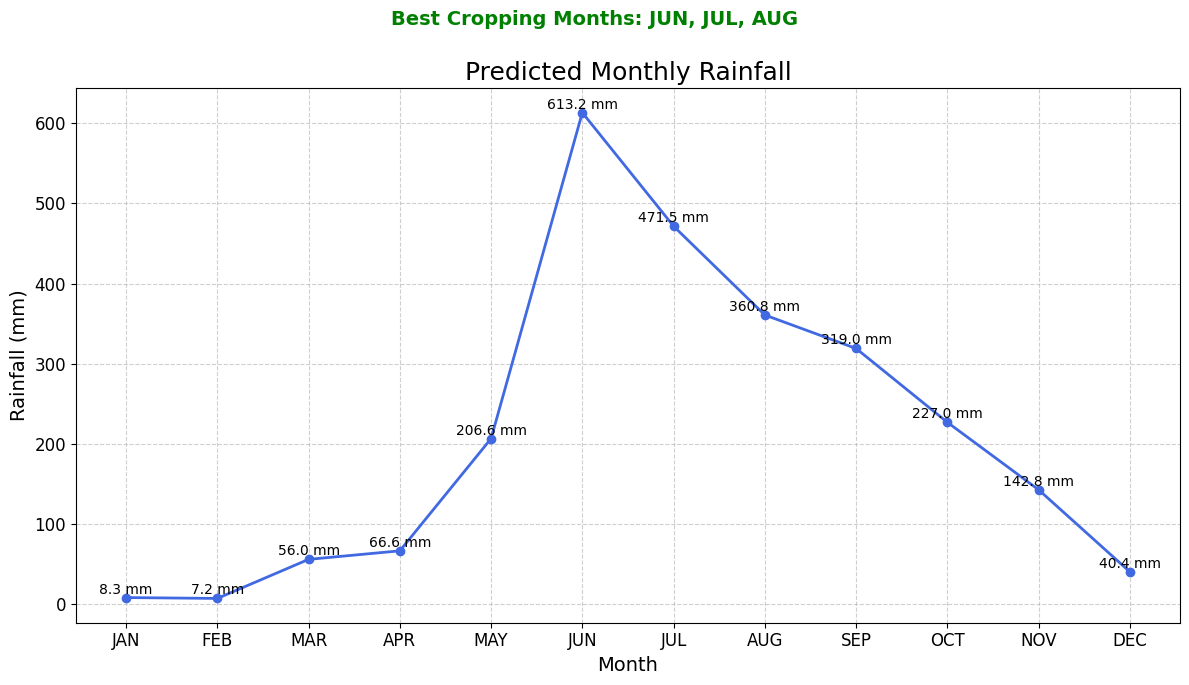

In [50]:

# ✅ Encode Categorical Inputs
state_enc = le_state.transform([user_state])[0]
soil_enc = le_soil.transform([user_soil])[0]
crop_enc = le_crop.transform([user_crop])[0]

# ✅ Predict Monthly Rainfall
rainfall_input = pd.DataFrame([[state_enc, predict_year]], columns=['state_enc', 'year'])
print("Rainfall input columns:", rainfall_input.columns.tolist())
print(rainfall_input)
print("Model expects:", rainfall_model.estimators_[0].feature_names_in_)
monthly_rainfall = rainfall_model.predict(rainfall_input)[0]
annual_rainfall = np.sum(monthly_rainfall)

print(f"🌧️ Predicted Annual Rainfall for {user_state} in {predict_year}: {annual_rainfall:.2f} mm")

# ✅ Create Rainfall DataFrame
months = ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN',
          'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC']
rainfall_df = pd.DataFrame({
    'Month': months,
    'Rainfall_mm': monthly_rainfall
})

# ✅ Get Top 3 Best Cropping Months
top_months = rainfall_df.sort_values(by='Rainfall_mm', ascending=False).head(3)
best_months_text = ", ".join(top_months['Month'].values)
print(f"\n🌱 Best Cropping Months based on Rainfall: {best_months_text}")

# ✅ Predict Temperature & Humidity
temp_hum_input = pd.DataFrame([[state_enc, soil_enc, crop_enc, annual_rainfall]],
                              columns=['STATE_ENC', 'SOIL_ENC', 'CROP_ENC', 'RAINFALL'])
pred_temp, pred_hum = temp_hum_model.predict(temp_hum_input)[0]

print(f"\n🌡️ Predicted Temperature: {pred_temp:.2f} °C")
print(f"💧 Predicted Humidity: {pred_hum:.2f} %")

# ✅ Predict NPK values (Default pH)
ph_value = 6.5
npk_input = pd.DataFrame([[state_enc, soil_enc, crop_enc, pred_temp, pred_hum, annual_rainfall, ph_value]],
                         columns=['STATE_ENC', 'SOIL_ENC', 'CROP_ENC', 'TEMPERATURE', 'HUMIDITY', 'RAINFALL', 'ph'])
pred_N, pred_P, pred_K = npk_model.predict(npk_input)[0]

print("\n✅ Predicted NPK Values:")
print(f"🟢 Nitrogen (N): {pred_N:.2f}")
print(f"🟠 Phosphorous (P): {pred_P:.2f}")
print(f"🔵 Potassium (K): {pred_K:.2f}")

# ✅ Predict Crop Yield
yield_input = pd.DataFrame([{
    'crop_enc': crop_enc,
    'year': predict_year,
    'season_enc': 1,  # Assuming Kharif (1)
    'state_enc': state_enc,
    'area': user_area,
    'annual rainfall': annual_rainfall
}])

predicted_yield = max(0, yield_model.predict(yield_input)[0])
print(f"\n🌾 Predicted Yield: {predicted_yield:.2f} tons/hectare")

# ✅ Final Prediction Result DataFrame
result = pd.DataFrame({
    'State': [user_state],
    'Soil Type': [user_soil],
    'Crop': [user_crop],
    'Area (ha)': [user_area],
    'Predicted Rainfall (mm)': [annual_rainfall],
    'Temperature (°C)': [pred_temp],
    'Humidity (%)': [pred_hum],
    'Nitrogen (N)': [pred_N],
    'Phosphorous (P)': [pred_P],
    'Potassium (K)': [pred_K],
    'Yield (tons/ha)': [predicted_yield]
})


# ✅ Plot Rainfall Line Chart with Best Months Display
plt.figure(figsize=(12, 7))

plt.plot(rainfall_df['Month'], rainfall_df['Rainfall_mm'],
         marker='o', color='royalblue', linewidth=2)

plt.title('Predicted Monthly Rainfall', fontsize=18)
plt.xlabel('Month', fontsize=14)
plt.ylabel('Rainfall (mm)', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# ✅ Annotate Rainfall Values
for i, value in enumerate(rainfall_df['Rainfall_mm']):
    plt.text(i, value + 5, f'{value:.1f} mm', ha='center', fontsize=10)

# ✅ Display Best Cropping Months on Top
plt.figtext(0.5, 0.95, f'Best Cropping Months: {best_months_text}',
            fontsize=14, ha='center', color='green', fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()